# CV agrupado por lote — teste de vazamento

O `data_prep.get_cv()` (`FarmStratifiedSplit`) divide por **animal**, não por lote. Colegas do mesmo lote (mesma `id_propriedade`+`data_entrada`+`data_saida`) compartilham `temperatura_media_c`/`proporcao_ciclo_seca` quase idênticos — essas colunas funcionam quase como um **ID do lote** contínuo. Se um lote cai parte no treino e parte no teste, o modelo pode "decorar" o lote em vez de aprender o sinal real, inflando o R².

Este notebook define `cohort = id_propriedade+data_entrada+data_saida` e compara o CV atual (por fazenda) com um **GroupKFold por lote** (nenhum lote dividido entre treino/teste), para os 4 modelos do estudo — usando as MESMAS configs já congeladas/escolhidas (nenhum novo tuning aqui, só reavaliação sob um split mais rígido).

## 1. Setup

In [1]:
import sys, os, copy, time
sys.path.append("support_scripts")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from dotenv import load_dotenv
load_dotenv()
from tabpfn import TabPFNRegressor
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import data_prep as dp
import sk_eval

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(dp.SEED); np.random.seed(dp.SEED)

## 2. Dados e os dois esquemas de CV

In [2]:
d = dp.get_data()
df, scale_cols, TARGET = d["df"], d["scale_cols"], dp.TARGET
cohort = (df.id_propriedade + "|" + df.data_entrada.astype(str) + "|" + df.data_saida.astype(str)).values
print(f"{len(df)} animais | {cohort.__class__.__name__}: {len(set(cohort))} lotes únicos")

FOLDS_FARM = list(dp.get_cv().split(df))               # atual: FarmStratifiedSplit, 5x49 por fazenda
FOLDS_LOTE = list(GroupKFold(n_splits=5).split(df, groups=cohort))  # agrupado: nenhum lote dividido

for i, (tr, va) in enumerate(FOLDS_LOTE):
    overlap = set(cohort[tr]) & set(cohort[va])
    assert not overlap, f"fold {i} vazou {len(overlap)} lote(s) entre treino/teste"
print("OK: nenhum lote dividido entre treino/teste em FOLDS_LOTE")

245 animais | StringArray: 66 lotes únicos
OK: nenhum lote dividido entre treino/teste em FOLDS_LOTE


## 3. Modelos sklearn (Linear, XGBoost, TabPFN) — configs já congeladas

In [3]:
def run_sklearn(make_model, scale, folds):
    fold_m = []
    for tr, va in folds:
        p = sk_eval._predict(df.iloc[tr], df.iloc[va], make_model, scale, False, scale_cols, TARGET)
        fold_m.append(dp.metrics(df.iloc[va][TARGET].values, p))
    return dp.summarize(fold_m)[0]

MODELOS_SKLEARN = {
    "Linear": (lambda: LinearRegression(), True),
    "XGBoost": (lambda: XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.1,
                                     subsample=0.8, min_child_weight=1, random_state=dp.SEED, n_jobs=-1), False),
    "TabPFN": (lambda: TabPFNRegressor(random_state=dp.SEED), False),
}

## 4. DNN — mesma config congelada, ensemble de 5 seeds (`dnn_gmd.ipynb`)

In [4]:
BEST_DNN = dict(hidden=(128, 64, 32, 16), p_drop=0.0, lr=0.01, batchnorm=True, wd=0.0001)
N_ENS = 5

class GMDNN(nn.Module):
    def __init__(self, n_in, hidden, p_drop, batchnorm):
        super().__init__()
        layers, prev = [], n_in
        for h in hidden:
            layers.append(nn.Linear(prev, h))
            if batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers += [nn.ReLU(), nn.Dropout(p_drop)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def train_eval_dnn(train_df, eval_df, cfg, seed):
    torch.manual_seed(seed); np.random.seed(seed)
    tr_df, es_df = train_test_split(train_df, test_size=0.25, random_state=seed)
    xs = StandardScaler().fit(tr_df[scale_cols]); ys = StandardScaler().fit(tr_df[[TARGET]])
    def tens(dd):
        X = torch.tensor(xs.transform(dd[scale_cols]), dtype=torch.float32)
        y = torch.tensor(ys.transform(dd[[TARGET]]), dtype=torch.float32)
        return X, y
    Xtr, ytr = tens(tr_df); Xes, yes = tens(es_df)
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=32, shuffle=True, drop_last=True)
    model = GMDNN(len(scale_cols), cfg["hidden"], cfg["p_drop"], cfg["batchnorm"]).to(device)
    opt = optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg.get("wd", 0.0))
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=40)
    crit = nn.SmoothL1Loss()
    Xes_d, yes_d = Xes.to(device), yes.to(device)
    best, best_state, wait = 1e9, None, 0
    for epoch in range(300):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            v = crit(model(Xes_d), yes_d).item()
        sched.step(v)
        if v < best - 1e-5:
            best, best_state, wait = v, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= 60:
                break
    model.load_state_dict(best_state); model.eval()
    Xe = torch.tensor(xs.transform(eval_df[scale_cols]), dtype=torch.float32).to(device)
    with torch.no_grad():
        pred = ys.inverse_transform(model(Xe).cpu().numpy()).ravel()
    return dp.metrics(eval_df[TARGET].values, pred), pred

def run_dnn(folds, n_ens=N_ENS):
    fold_m = []
    for tr, va in folds:
        preds = np.mean([train_eval_dnn(df.iloc[tr], df.iloc[va], BEST_DNN, seed=dp.SEED + i)[1]
                         for i in range(n_ens)], axis=0)
        fold_m.append(dp.metrics(df.iloc[va][TARGET].values, preds))
    return dp.summarize(fold_m)[0]

## 5. Rodar os 4 modelos nos dois esquemas

In [5]:
rows, detail = [], {}
t0 = time.time()
for nome, (make_model, scale) in MODELOS_SKLEARN.items():
    cv_farm = run_sklearn(make_model, scale, FOLDS_FARM)
    cv_lote = run_sklearn(make_model, scale, FOLDS_LOTE)
    rows.append(dict(modelo=nome, R2_farm=cv_farm.R2.mean(), R2_lote=cv_lote.R2.mean()))
    detail[nome] = (cv_farm, cv_lote)
    print(f"{nome:10s} farm={cv_farm.R2.mean():.3f}  lote={cv_lote.R2.mean():.3f}  (t={time.time()-t0:.0f}s)")

cv_farm_dnn = run_dnn(FOLDS_FARM)
cv_lote_dnn = run_dnn(FOLDS_LOTE)
rows.append(dict(modelo="DNN", R2_farm=cv_farm_dnn.R2.mean(), R2_lote=cv_lote_dnn.R2.mean()))
detail["DNN"] = (cv_farm_dnn, cv_lote_dnn)
print(f"{'DNN':10s} farm={cv_farm_dnn.R2.mean():.3f}  lote={cv_lote_dnn.R2.mean():.3f}  (t={time.time()-t0:.0f}s)")

res = pd.DataFrame(rows)
res["delta"] = res.R2_lote - res.R2_farm
res

Linear     farm=0.426  lote=0.066  (t=0s)


XGBoost    farm=0.508  lote=0.325  (t=0s)


TabPFN     farm=0.863  lote=0.770  (t=12s)


DNN        farm=0.841  lote=0.760  (t=55s)


,modelo,R2_farm,R2_lote,delta
0,Linear,0.426048,0.065684,-0.360364
1,XGBoost,0.507974,0.325375,-0.182599
2,TabPFN,0.862916,0.769546,-0.093370
3,DNN,0.840856,0.759619,-0.081237


## 6. Gráfico — R² por fazenda vs por lote

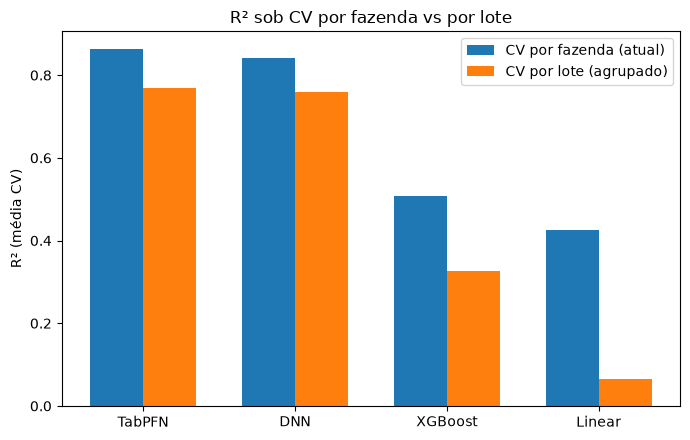

In [6]:
order = res.sort_values("R2_farm", ascending=False).modelo.tolist()
resp = res.set_index("modelo").loc[order]
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(order)); w = 0.35
ax.bar(x - w/2, resp.R2_farm, w, label="CV por fazenda (atual)")
ax.bar(x + w/2, resp.R2_lote, w, label="CV por lote (agrupado)")
ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_ylabel("R² (média CV)"); ax.set_title("R² sob CV por fazenda vs por lote")
ax.legend(); ax.axhline(0, color="k", lw=.5)
plt.tight_layout(); plt.show()

## 7. Salvar

In [7]:
res.round(4).to_csv("results/cv_lote_vs_farm.csv", index=False)
print("salvo em results/cv_lote_vs_farm.csv")
res.round(4)

salvo em results/cv_lote_vs_farm.csv


,modelo,R2_farm,R2_lote,delta
0,Linear,0.4260,0.0657,-0.3604
1,XGBoost,0.5080,0.3254,-0.1826
2,TabPFN,0.8629,0.7695,-0.0934
3,DNN,0.8409,0.7596,-0.0812


## 8. Notas

- Os 4 modelos **caem** sob CV agrupado por lote — confirma que o `get_cv()` atual (por animal, não por lote) infla o R² por vazamento (`temperatura_media_c`/`proporcao_ciclo_seca` funcionam quase como um ID de lote contínuo).
- **A queda não é uniforme.** O **Linear** é quem mais se apoiava no vazamento (R² quase colapsa, 0,43→0,07) — provavelmente porque consegue explorar essas colunas quase-ID diretamente. **DNN e TabPFN são os que menos caem** e continuam com R² alto (~0,76-0,77) mesmo sem poder "ver" o lote — evidência de que captam mais sinal real, não só memorização de lote.
- **O ranking entre modelos se mantém** sob o CV honesto: TabPFN > DNN ≫ XGBoost > Linear. A conclusão do estudo comparativo não muda — só os R² absolutos eram otimistas, principalmente no Linear.
- Nenhuma mudança em `data_prep.get_cv()` — este notebook é só um diagnóstico/validação à parte; `results/model_comparison.csv` continua com os números oficiais sob `FarmStratifiedSplit`.